# YOLOv8 Object Detection

This notebook trains a YOLOv8 object detection model on a VOC-style dataset of four classes (car, bus, bicycle, motorbike). It covers preparing the data, configuring the YOLO training run, and saving the trained weights.

## 1. Training

In [1]:
from ultralytics import YOLO
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

model = YOLO('yolov8n.pt')

results = model.train(
    data='../yolo_data/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    seed=SEED,
    project='voc_detection',
    name='exp1',
    deterministic=True,
    
    patience=50,             
    lr0=0.001,               
    optimizer='AdamW',       
    
    mosaic=1.0,              
    fliplr=0.5,               
    flipud=0.0,              
    hsv_h=0.015,             
    hsv_s=0.7,               
    hsv_v=0.4,               
    scale=0.5,               
    translate=0.1            
)

/Users/javidalakbarli/Downloads/voc-detection/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


New https://pypi.org/project/ultralytics/8.4.20 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../yolo_data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, 

## 2. Results

--- Training & Validation Metrics ---


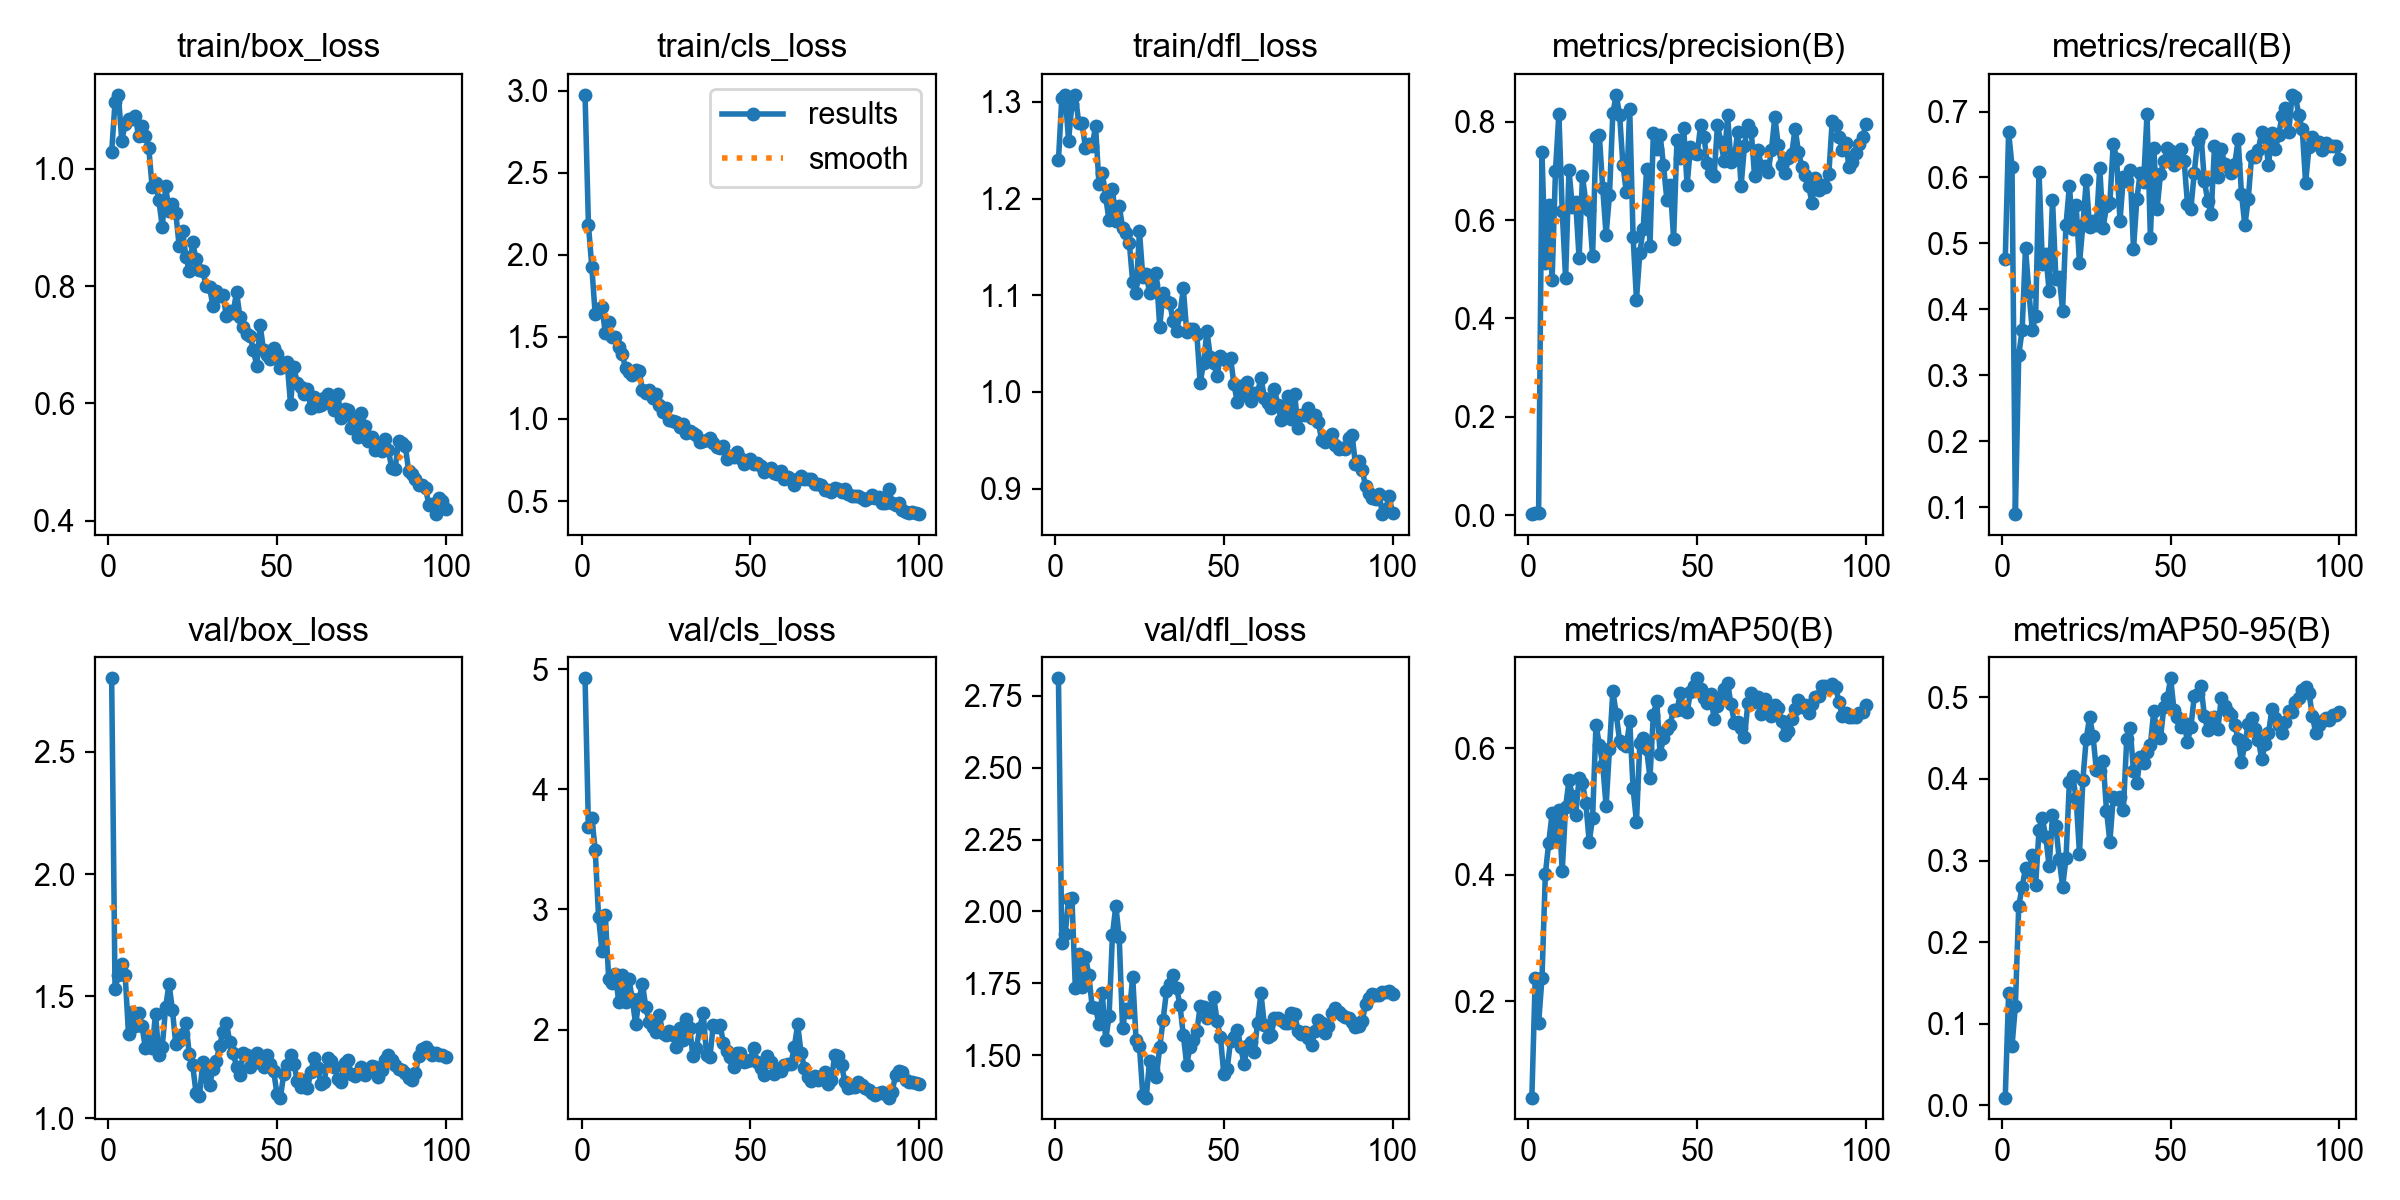

--- Normalized Confusion Matrix ---


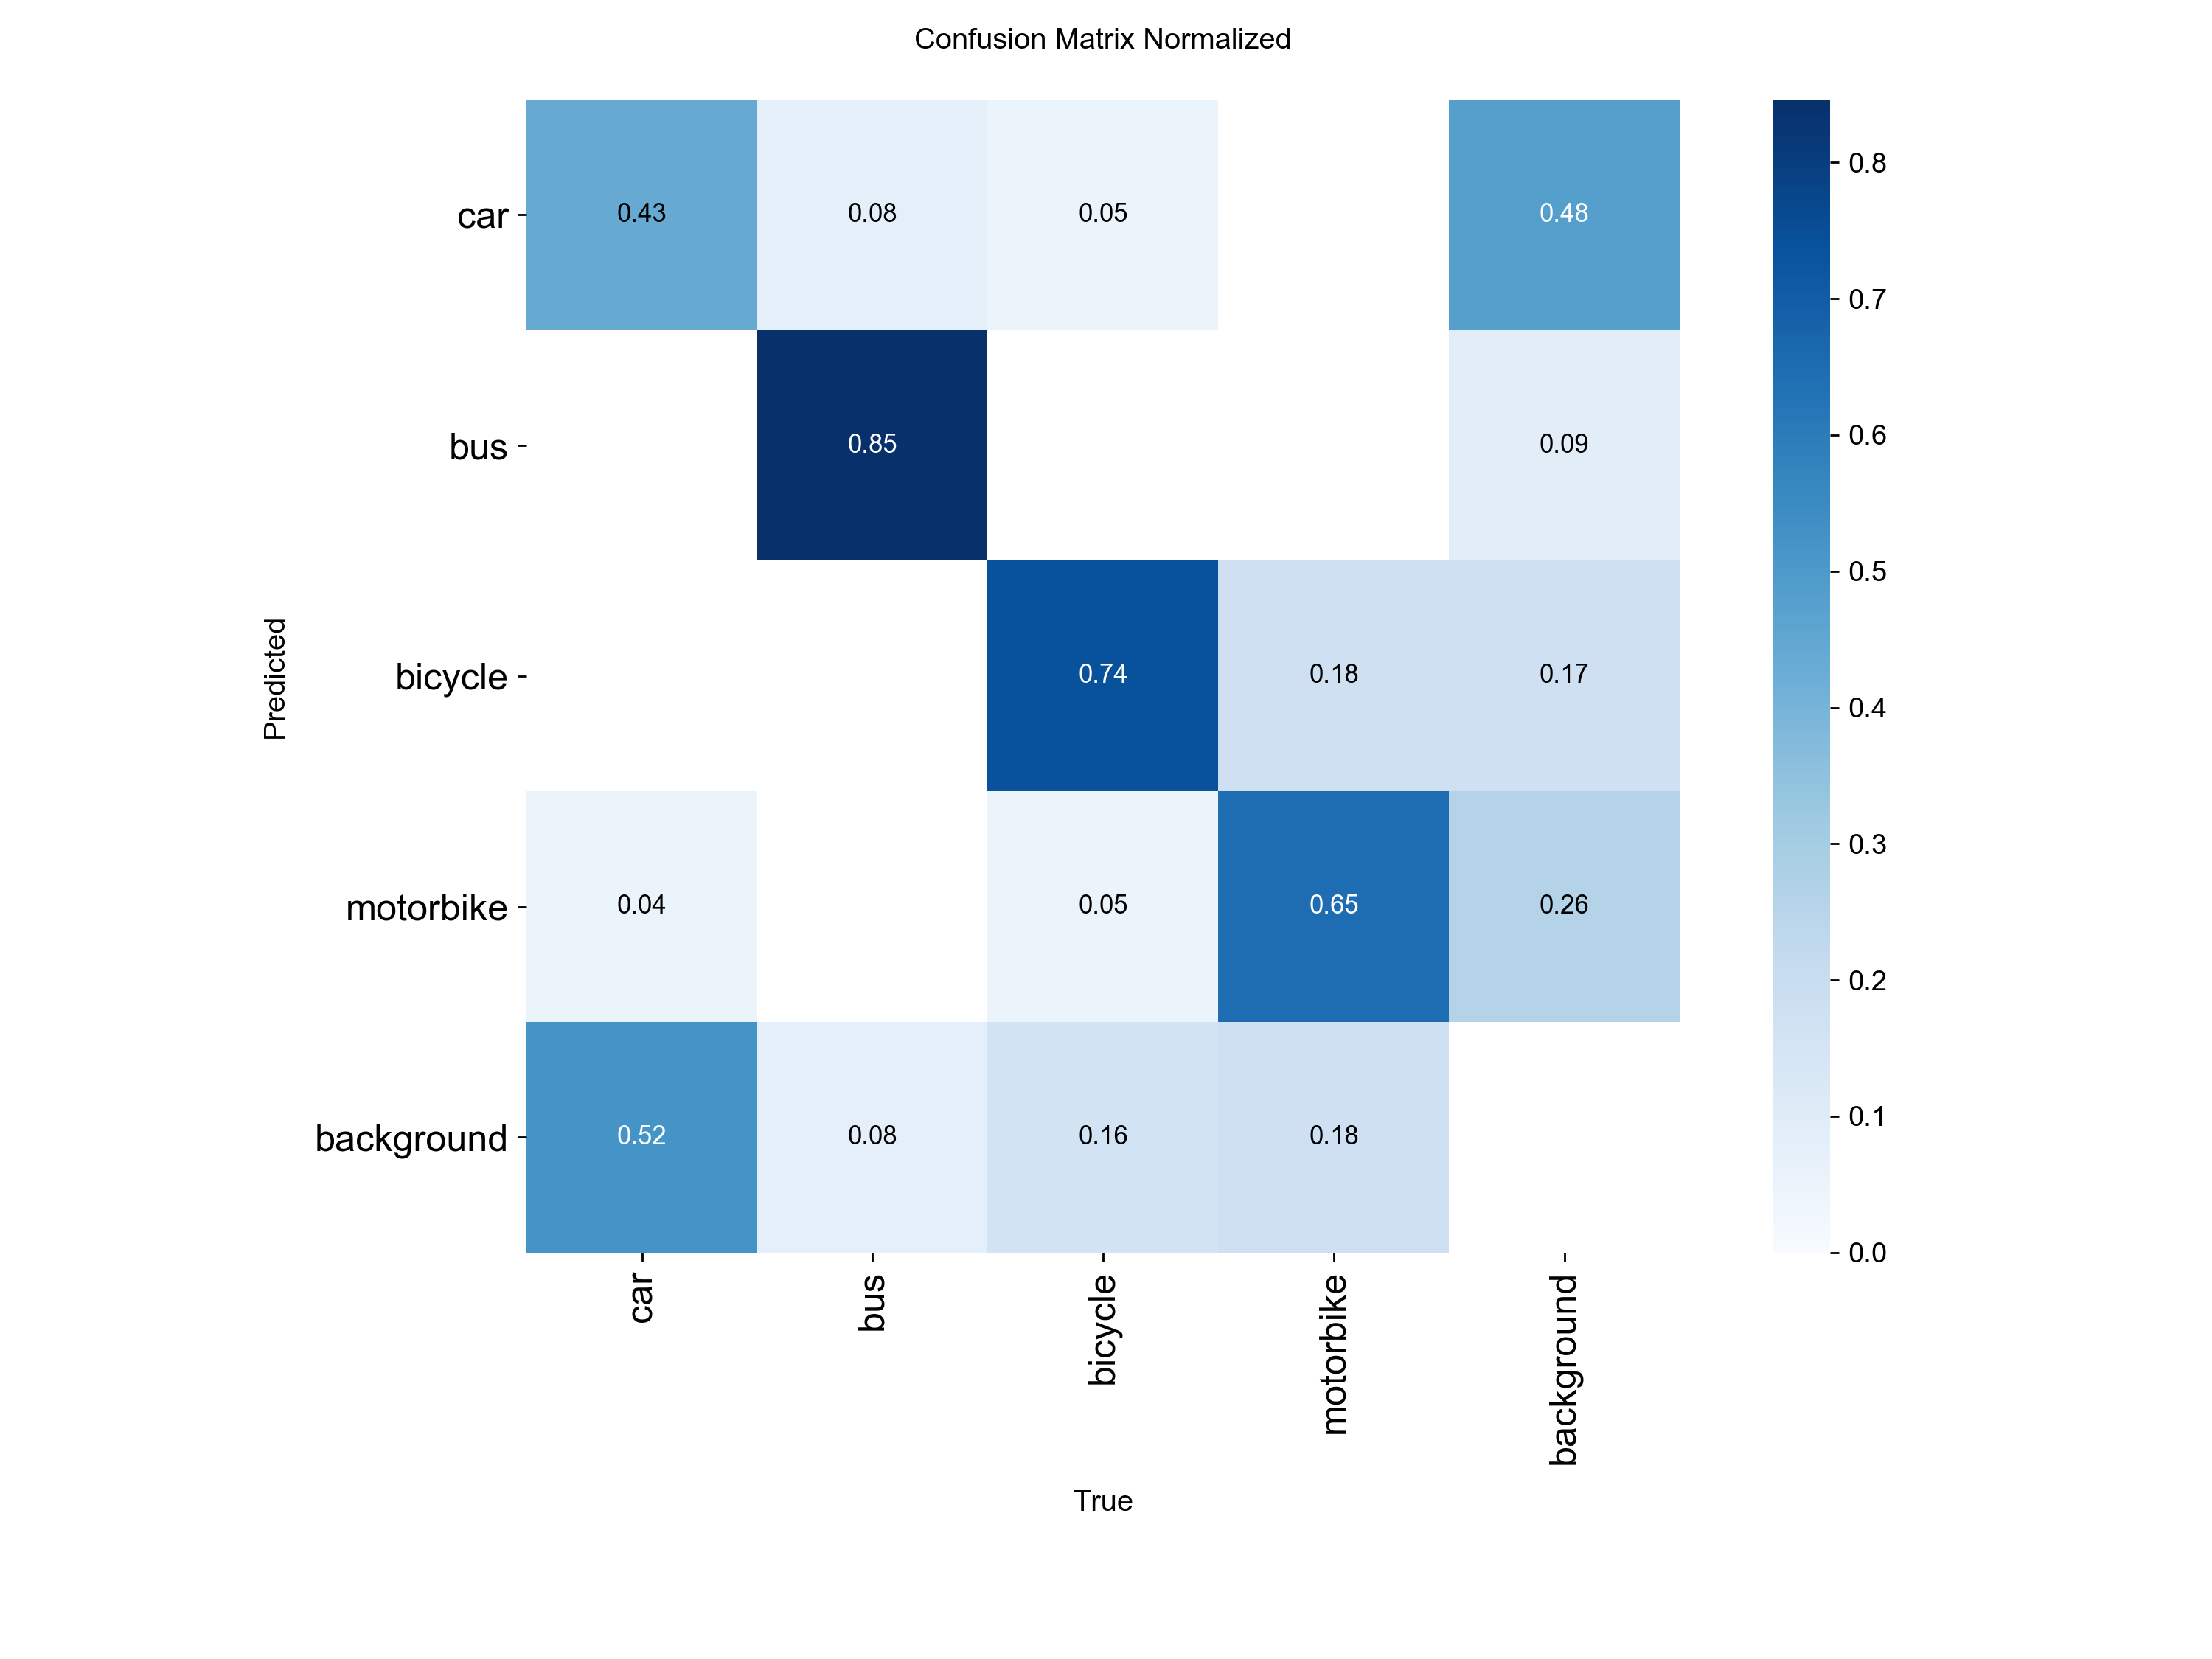

--- Validation Predictions (Sample) ---


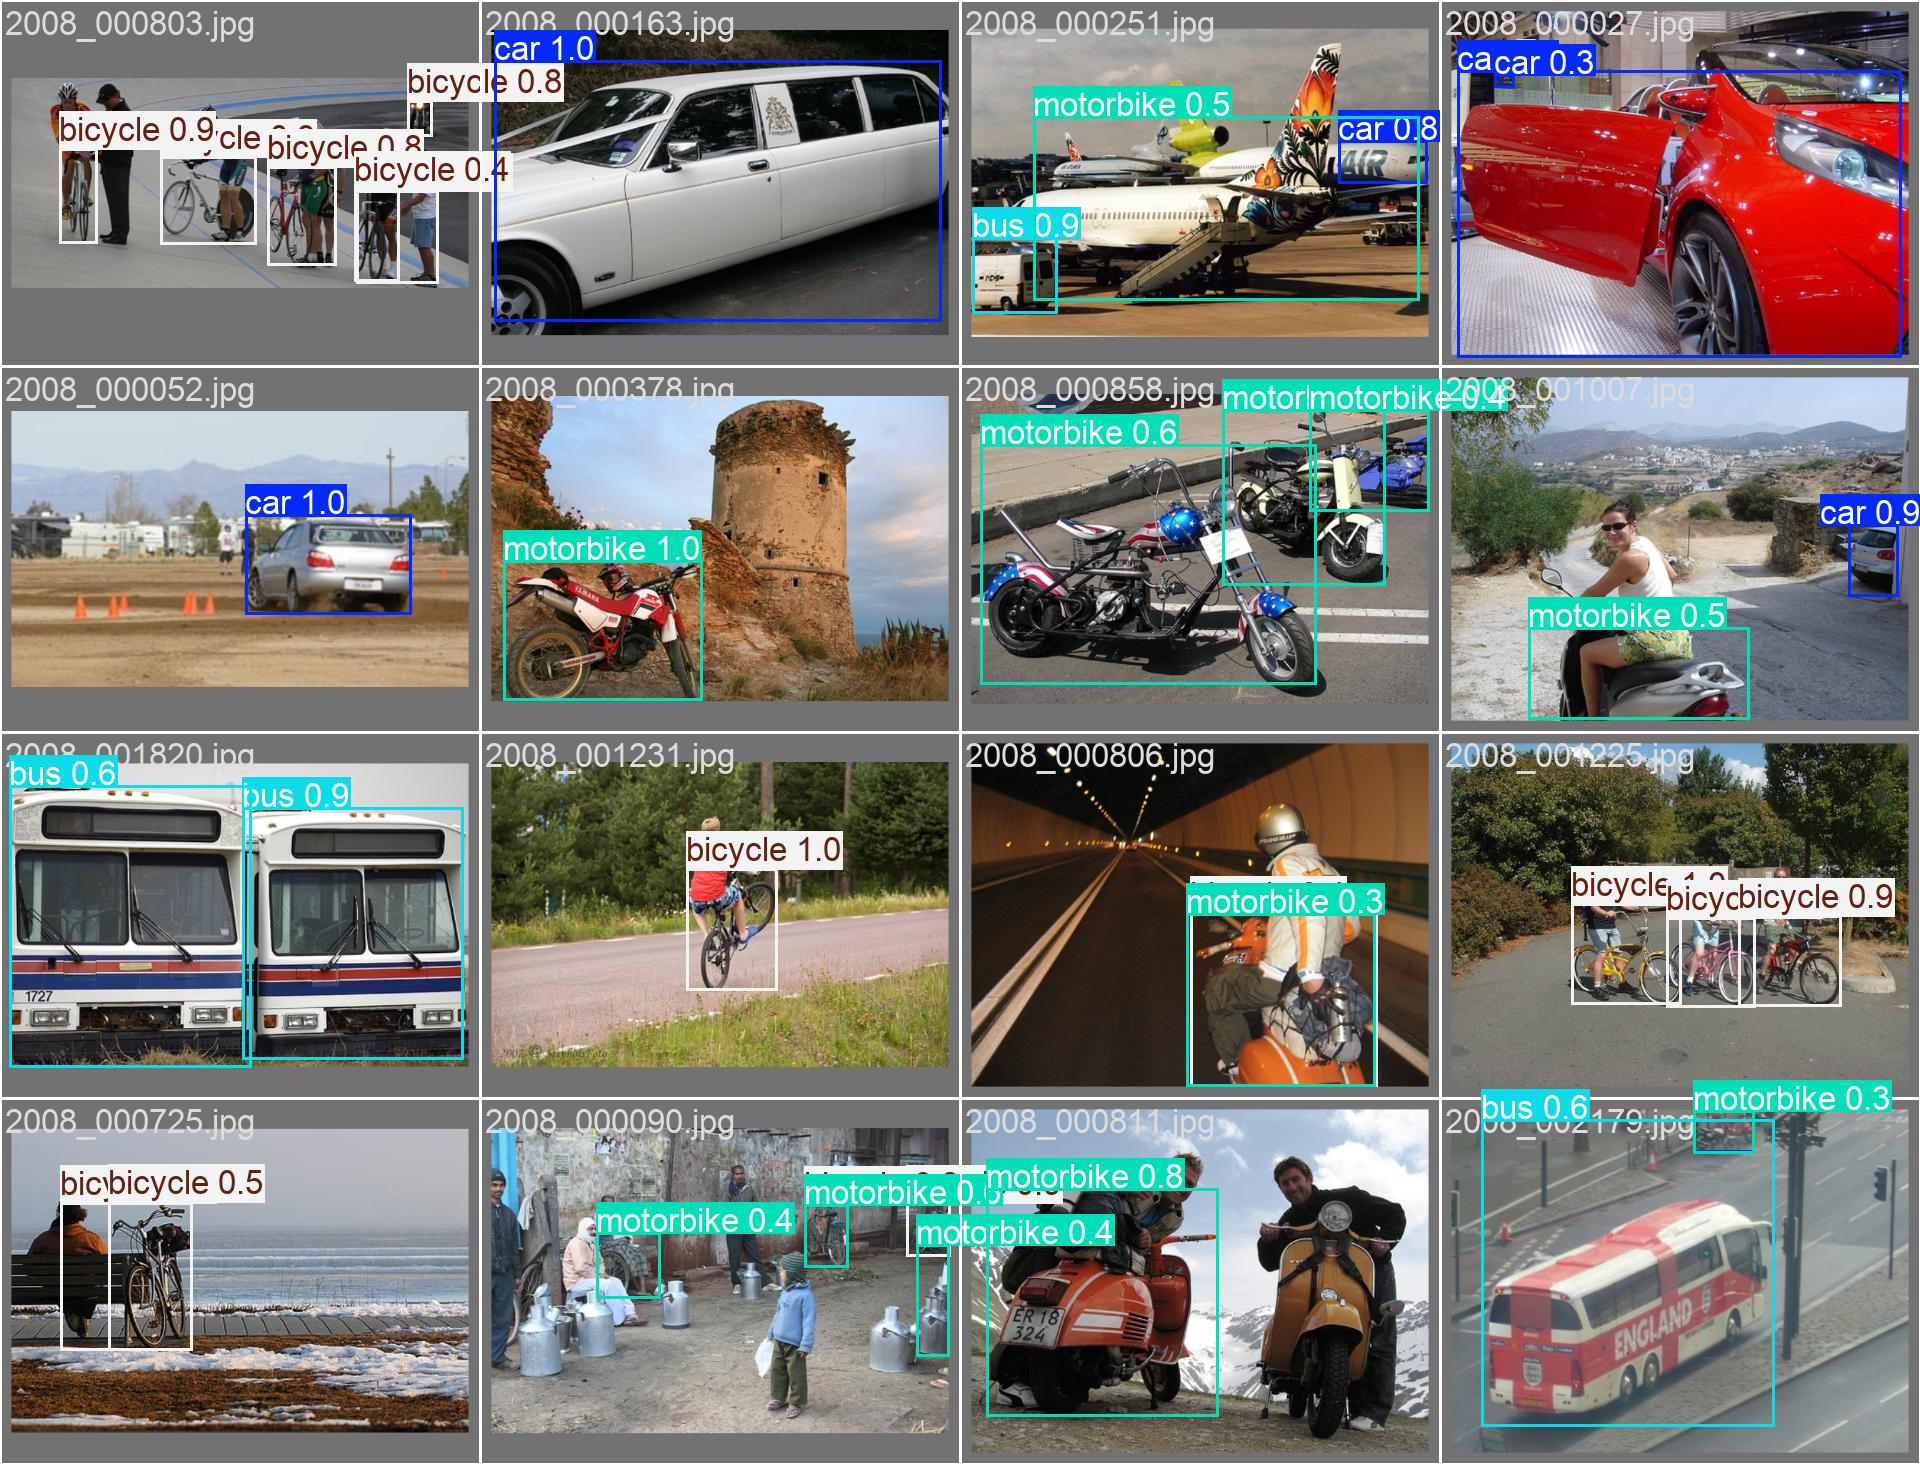

--- Validation Ground Truth (Sample) ---


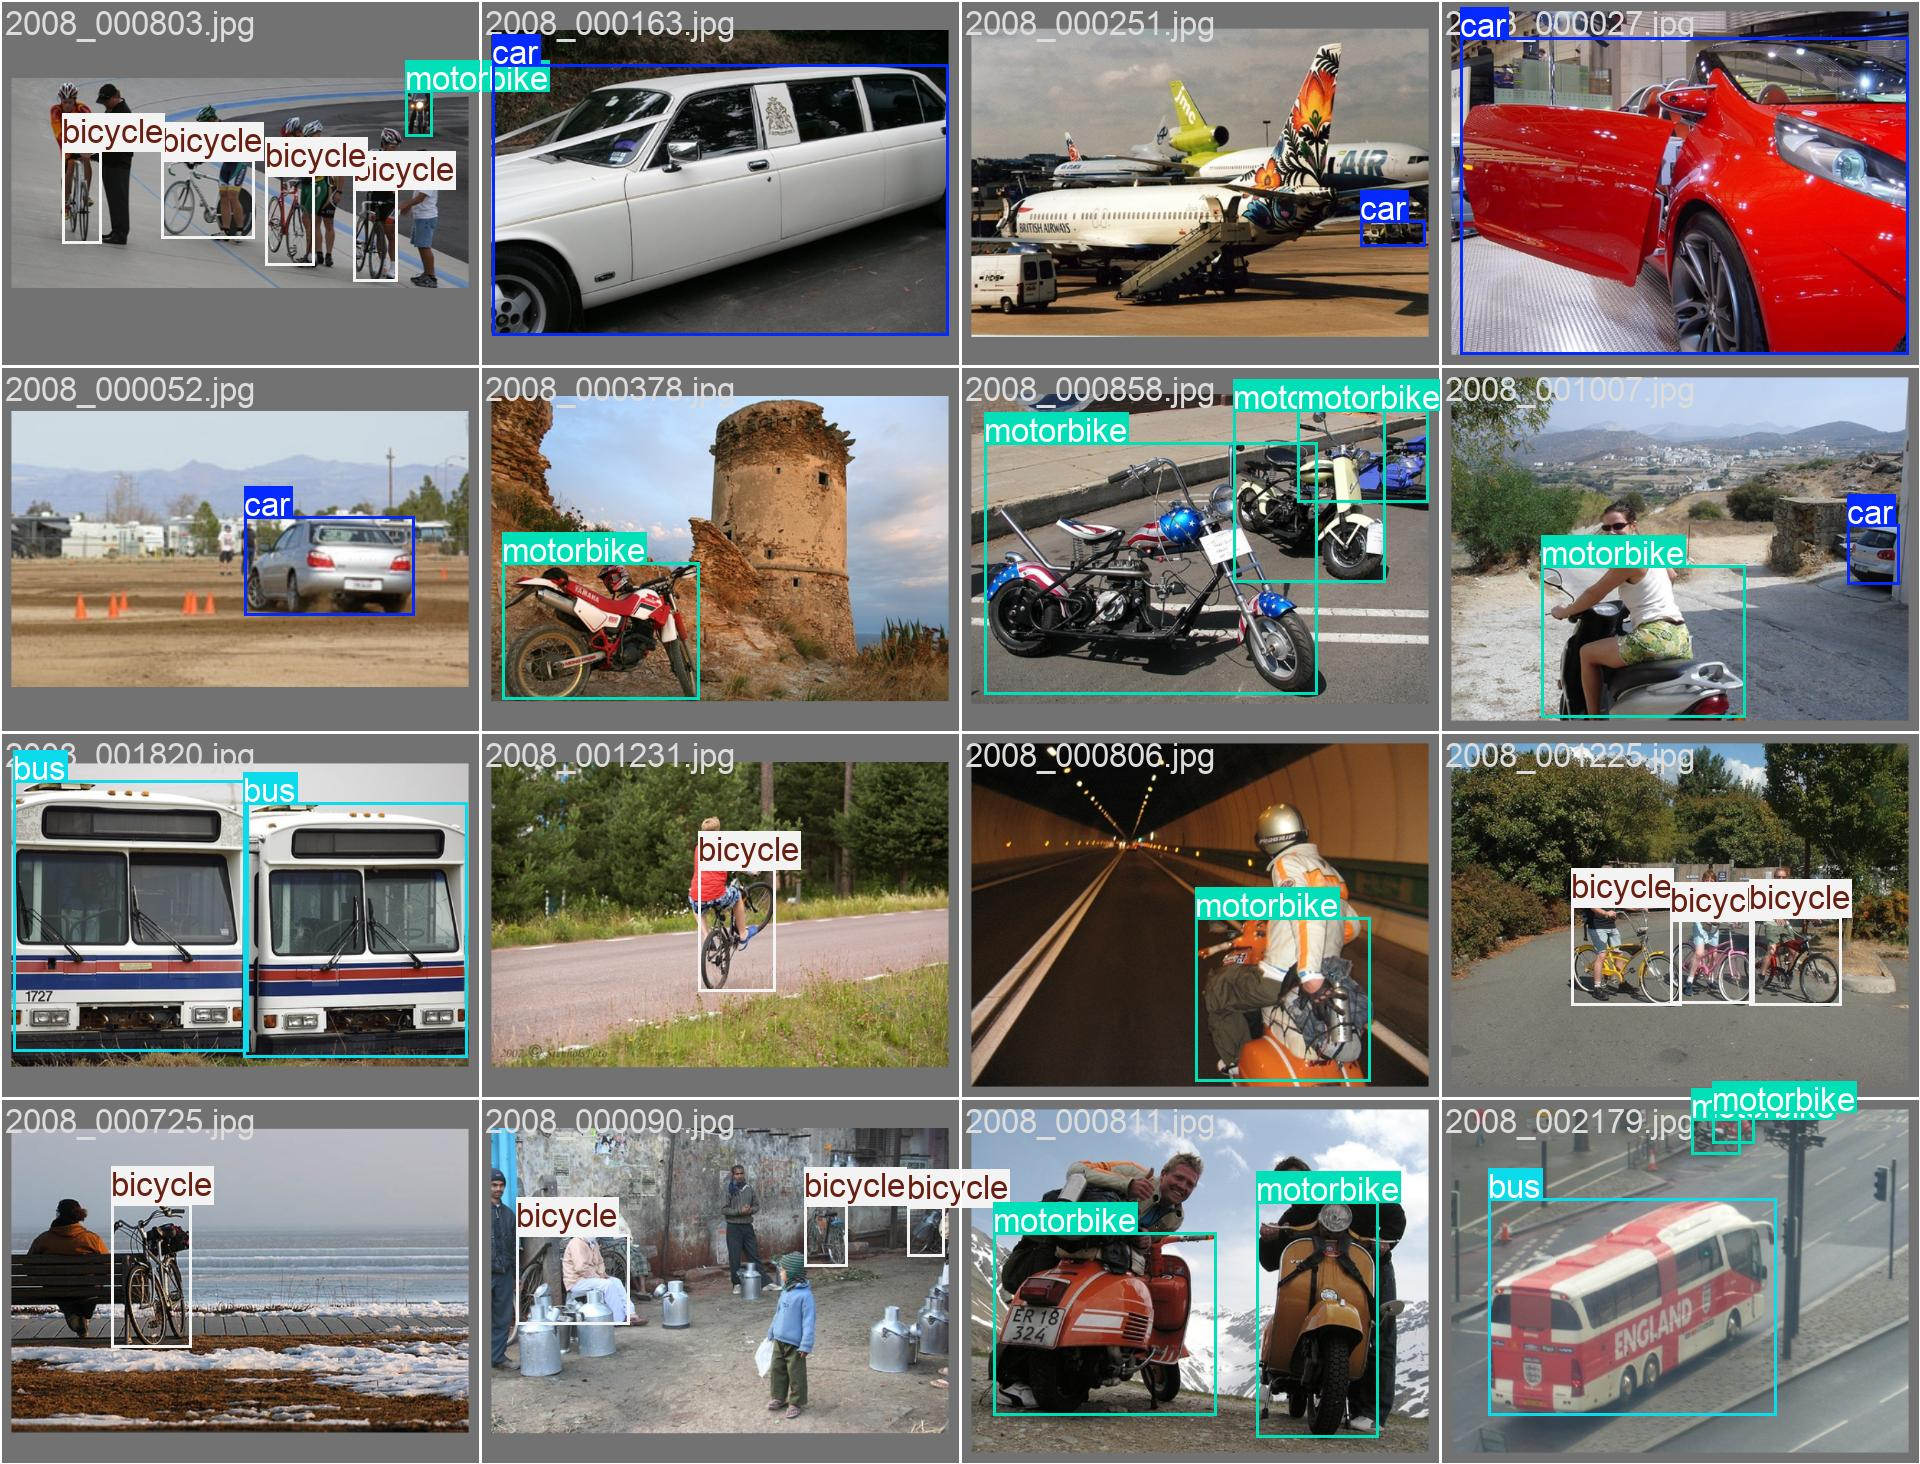

In [3]:
import os
from IPython.display import Image, display

run_dir = 'runs/detect/voc_detection/exp1' 

visualizations = [
    ('Training & Validation Metrics', 'results.png'), 
    ('Normalized Confusion Matrix', 'confusion_matrix_normalized.png'),
    ('Validation Predictions (Sample)', 'val_batch0_pred.jpg'),
    ('Validation Ground Truth (Sample)', 'val_batch0_labels.jpg')
]

for title, file_name in visualizations:
    file_path = os.path.join(run_dir, file_name)
    
    if os.path.exists(file_path):
        print(f"--- {title} ---")
        display(Image(filename=file_path, width=800))